# 🛰️🔥 OrbitalFire — Detecção de Queimadas em Imagens de Satélite (ACV)

**Disciplina:** Applied Computer Vision (ACV)
**Global Solution 2026 · 1º Semestre · Indústria Espacial · FIAP · Eng. de Software · 4º Ano**
**ODS:** 13 — Ação Climática

**Integrantes:**
- Bruno Eduardo Caputo Paulino — RM 558303

---

## 1. Definição do problema de visão computacional

A solução integrada **OrbitalFire** monitora risco de queimadas via dados orbitais.
Este módulo (ACV) resolve a etapa de **percepção visual**: dada uma imagem de satélite
de uma área, classificá-la em **`wildfire`** (com indício de incêndio/queimada) ou
**`nowildfire`** (sem indício).

Na arquitetura da solução, este classificador atua como **validação visual** do alerta:
quando o modelo de risco (GAIE) ou o pipeline (BDDI) sinaliza uma região, a imagem
orbital correspondente é classificada para confirmar/descartar o foco — reduzindo
falsos positivos antes de acionar a defesa civil. Conexão direta com a Indústria
Espacial: **a entrada é imagem de satélite de observação da Terra**.

Problema: **classificação binária de imagens** com **CNNs treinadas do zero**
(sem modelos pré-treinados), mirando **acurácia ≥ 88%** no conjunto de teste.

## 2. Dataset utilizado

**Wildfire Prediction Dataset (Satellite Images)** — Kaggle
(`abdelghaniaaba/wildfire-prediction-dataset`).

- Imagens de satélite (~350×350 px, RGB) de regiões do Canadá rotuladas a partir de
  dados oficiais de incêndios florestais.
- **2 classes:** `wildfire` e `nowildfire`.
- Já dividido em **train / valid / test** (divisão oficial do dataset — evitamos
  vazamento entre treino e teste).
- ~42 mil imagens no total (classes aproximadamente balanceadas).

Pré-processamento: redimensionamento para 128×128, normalização `[0,1]` (camada
`Rescaling`) e **data augmentation** (flip, rotação, zoom) aplicado igualmente aos
dois modelos para uma comparação justa.

In [5]:
# === Imports e configuração ===
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

IMG_SIZE = (128, 128)
BATCH = 32
EPOCHS = 20
print("TensorFlow:", tf.__version__)
print("GPU disponível:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.19.0
GPU disponível: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [6]:
DATA_DIR = "/kaggle/input/datasets/abdelghaniaaba/wildfire-prediction-dataset"

# --- Colab / local via kagglehub (descomente se necessário) ---
# import kagglehub
# DATA_DIR = kagglehub.dataset_download("abdelghaniaaba/wildfire-prediction-dataset")

assert DATA_DIR, "Dataset não encontrado. Adicione o dataset do Kaggle ou ajuste DATA_DIR."
TRAIN_DIR = os.path.join(DATA_DIR, "train")
VALID_DIR = os.path.join(DATA_DIR, "valid")
TEST_DIR  = os.path.join(DATA_DIR, "test")
print("DATA_DIR:", DATA_DIR)
print("Subpastas:", os.listdir(DATA_DIR))

DATA_DIR: /kaggle/input/datasets/abdelghaniaaba/wildfire-prediction-dataset
Subpastas: ['valid', 'test', 'train']


In [7]:
# === Construção dos datasets tf.data ===
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, labels="inferred", label_mode="binary",
    image_size=IMG_SIZE, batch_size=BATCH, shuffle=True, seed=SEED)
valid_ds = tf.keras.utils.image_dataset_from_directory(
    VALID_DIR, labels="inferred", label_mode="binary",
    image_size=IMG_SIZE, batch_size=BATCH, shuffle=False)
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR, labels="inferred", label_mode="binary",
    image_size=IMG_SIZE, batch_size=BATCH, shuffle=False)

CLASS_NAMES = train_ds.class_names
print("Classes:", CLASS_NAMES)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
valid_ds = valid_ds.prefetch(AUTOTUNE)
test_ds  = test_ds.prefetch(AUTOTUNE)

Found 30250 files belonging to 2 classes.


I0000 00:00:1780981879.286363     125 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780981879.292553     125 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 6300 files belonging to 2 classes.
Found 6300 files belonging to 2 classes.
Classes: ['nowildfire', 'wildfire']


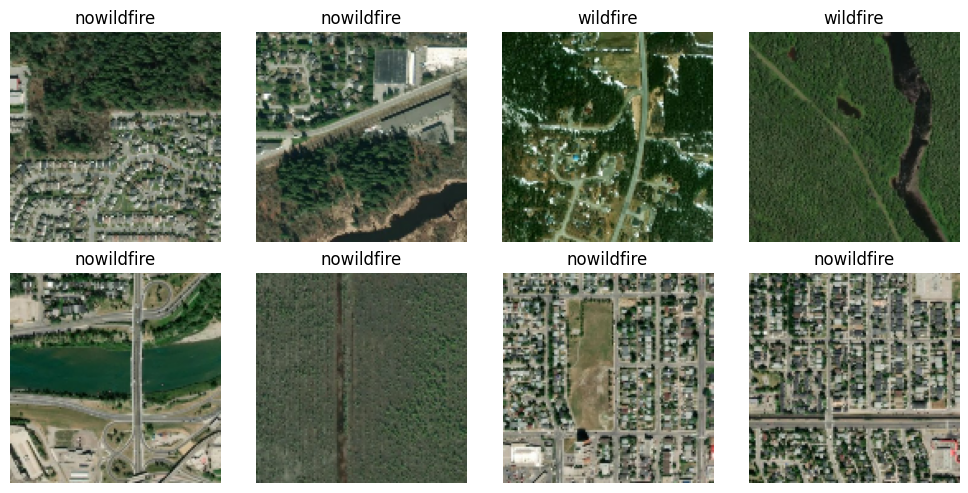

In [8]:
# === Visualizar amostras do dataset ===
plt.figure(figsize=(10, 5))
for imgs, labels in train_ds.take(1):
    for i in range(8):
        plt.subplot(2, 4, i + 1)
        plt.imshow(imgs[i].numpy().astype("uint8"))
        plt.title(CLASS_NAMES[int(labels[i].numpy()[0])])
        plt.axis("off")
plt.tight_layout(); plt.show()

## 3. Treinamento das CNNs do zero

Duas arquiteturas **autorais** (sem qualquer peso pré-treinado):

- **Modelo A — CNN-Base:** baseline simples, 3 blocos `Conv → MaxPool` + `Flatten` +
  `Dense`. Sem normalização nem regularização.
- **Modelo B — CNN-Plus:** mais profunda, 4 blocos com **BatchNormalization**,
  **GlobalAveragePooling** (em vez de Flatten) e **Dropout**. Espera-se que generalize
  melhor e atinja a referência de 88%.

A mesma `data_augmentation` é aplicada aos dois (comparação controlada: a diferença é
arquitetural).

In [9]:
# === Data augmentation (igual para os dois modelos) ===
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
], name="data_augmentation")

def aplicar_aug(ds):
    return ds.map(lambda x, y: (data_augmentation(x, training=True), y),
                  num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

train_aug = aplicar_aug(
    tf.keras.utils.image_dataset_from_directory(
        TRAIN_DIR, labels="inferred", label_mode="binary",
        image_size=IMG_SIZE, batch_size=BATCH, shuffle=True, seed=SEED))

Found 30250 files belonging to 2 classes.


In [10]:
# === Arquitetura A: CNN-Base (do zero) ===
def build_cnn_base(input_shape=(*IMG_SIZE, 3)):
    return models.Sequential([
        layers.Input(shape=input_shape),
        layers.Rescaling(1./255),
        layers.Conv2D(32, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(),
        layers.Conv2D(128, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ], name="CNN_Base")

cnn_base = build_cnn_base()
cnn_base.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
cnn_base.summary()

Model: "CNN_Base"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,287,809 (16.36 MB)

 Trainable params: 4,287,809 (16.36 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# === Arquitetura B: CNN-Plus (do zero) ===
def build_cnn_plus(input_shape=(*IMG_SIZE, 3)):
    def bloco(x, f):
        x = layers.Conv2D(f, 3, padding="same", use_bias=False)(x)
        x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
        x = layers.Conv2D(f, 3, padding="same", use_bias=False)(x)
        x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
        return layers.MaxPooling2D()(x)
    inp = layers.Input(shape=input_shape)
    x = layers.Rescaling(1./255)(inp)
    for f in (32, 64, 128, 256):
        x = bloco(x, f)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.4)(x)
    out = layers.Dense(1, activation="sigmoid")(x)
    return models.Model(inp, out, name="CNN_Plus")

cnn_plus = build_cnn_plus()
cnn_plus.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
cnn_plus.summary()

Model: "CNN_Plus"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 32, 32, 128)    │             

 Total params: 1,241,185 (4.73 MB)

 Trainable params: 1,239,265 (4.73 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [13]:
# === Treino do Modelo A ===
train_aug = train_aug.apply(tf.data.experimental.ignore_errors())
valid_ds  = valid_ds.apply(tf.data.experimental.ignore_errors())
test_ds   = test_ds.apply(tf.data.experimental.ignore_errors())
cb_a = [EarlyStopping(patience=4, restore_best_weights=True, monitor="val_accuracy"),
        ModelCheckpoint("cnn_base.keras", save_best_only=True, monitor="val_accuracy")]
hist_a = cnn_base.fit(train_aug, validation_data=valid_ds, epochs=EPOCHS, callbacks=cb_a)

Instructions for updating:
Use `tf.data.Dataset.ignore_errors` instead.
Epoch 1/20
    348/Unknown 21s 59ms/step - accuracy: 0.9183 - loss: 0.2096

2026-06-09 05:18:09.642153: E tensorflow/core/lib/jpeg/jpeg_mem.cc:329] Premature end of JPEG data. Stopped at line 46/350


    944/Unknown 78s 82ms/step - accuracy: 0.9210 - loss: 0.2032

2026-06-09 05:19:07.618364: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-09 05:19:07.761410: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


    945/Unknown 80s 84ms/step - accuracy: 0.9210 - loss: 0.2032

...

945/945 ━━━━━━━━━━━━━━━━━━━━ 58s 61ms/step - accuracy: 0.9660 - loss: 0.0901 - val_accuracy: 0.9524 - val_loss: 0.1328
Epoch 15/20
348/945 ━━━━━━━━━━━━━━━━━━━━ 34s 57ms/step - accuracy: 0.9686 - loss: 0.0859

2026-06-09 05:32:26.107115: E tensorflow/core/lib/jpeg/jpeg_mem.cc:329] Premature end of JPEG data. Stopped at line 46/350


945/945 ━━━━━━━━━━━━━━━━━━━━ 58s 61ms/step - accuracy: 0.9681 - loss: 0.0860 - val_accuracy: 0.9614 - val_loss: 0.1110
Epoch 16/20
353/945 ━━━━━━━━━━━━━━━━━━━━ 33s 56ms/step - accuracy: 0.9680 - loss: 0.0825

2026-06-09 05:33:24.223644: E tensorflow/core/lib/jpeg/jpeg_mem.cc:329] Premature end of JPEG data. Stopped at line 46/350


945/945 ━━━━━━━━━━━━━━━━━━━━ 58s 61ms/step - accuracy: 0.9682 - loss: 0.0842 - val_accuracy: 0.9597 - val_loss: 0.1140


In [14]:
# === Treino do Modelo B ===
cb_b = [EarlyStopping(patience=4, restore_best_weights=True, monitor="val_accuracy"),
        ModelCheckpoint("cnn_plus.keras", save_best_only=True, monitor="val_accuracy")]
hist_b = cnn_plus.fit(train_aug, validation_data=valid_ds, epochs=EPOCHS, callbacks=cb_b)

Epoch 1/20


2026-06-09 05:38:26.828882: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-09 05:38:26.984636: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-09 05:38:28.411215: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-09 05:38:28.706119: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


    339/Unknown 36s 61ms/step - accuracy: 0.8901 - loss: 0.2644

2026-06-09 05:38:53.907231: E tensorflow/core/lib/jpeg/jpeg_mem.cc:329] Premature end of JPEG data. Stopped at line 46/350


    944/Unknown 73s 61ms/step - accuracy: 0.9062 - loss: 0.2326

...

945/945 ━━━━━━━━━━━━━━━━━━━━ 62s 65ms/step - accuracy: 0.9646 - loss: 0.0987 - val_accuracy: 0.9278 - val_loss: 0.2286
Epoch 11/20
339/945 ━━━━━━━━━━━━━━━━━━━━ 36s 61ms/step - accuracy: 0.9629 - loss: 0.0986

2026-06-09 05:49:20.618113: E tensorflow/core/lib/jpeg/jpeg_mem.cc:329] Premature end of JPEG data. Stopped at line 46/350


945/945 ━━━━━━━━━━━━━━━━━━━━ 62s 65ms/step - accuracy: 0.9654 - loss: 0.0967 - val_accuracy: 0.9597 - val_loss: 0.1425
Epoch 12/20
339/945 ━━━━━━━━━━━━━━━━━━━━ 36s 61ms/step - accuracy: 0.9663 - loss: 0.0929

2026-06-09 05:50:22.201964: E tensorflow/core/lib/jpeg/jpeg_mem.cc:329] Premature end of JPEG data. Stopped at line 46/350


945/945 ━━━━━━━━━━━━━━━━━━━━ 61s 65ms/step - accuracy: 0.9657 - loss: 0.0938 - val_accuracy: 0.9524 - val_loss: 0.1475


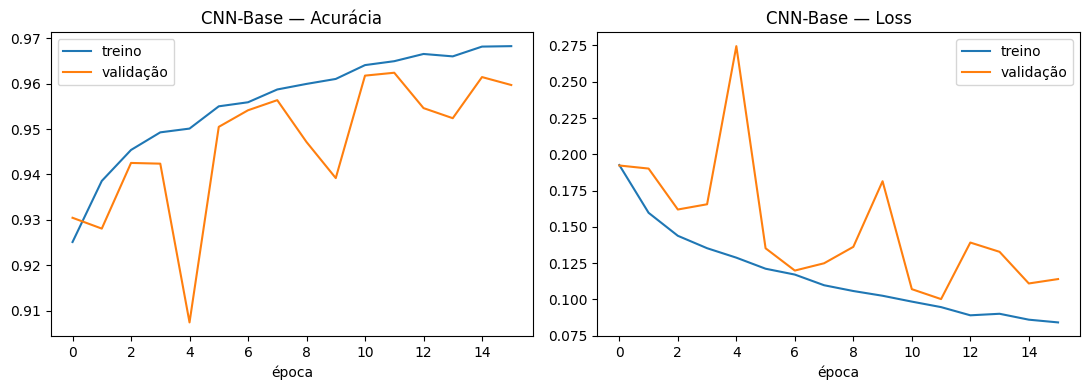

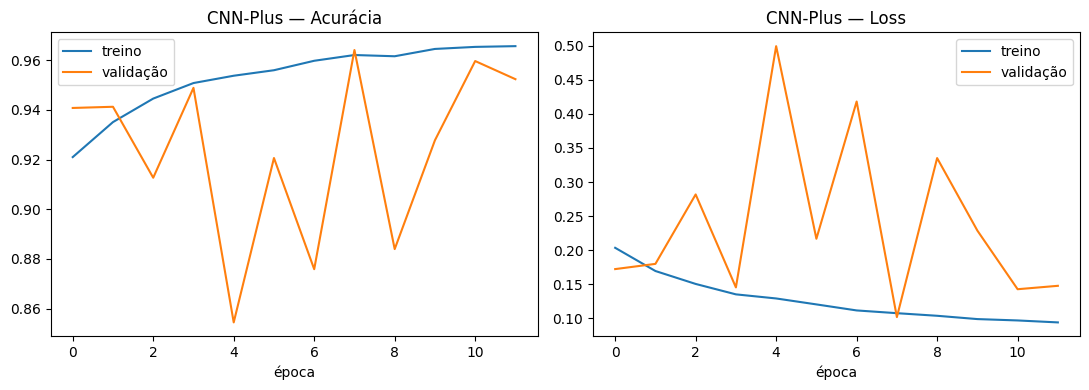

In [15]:
# === Curvas de acurácia e loss (evolução por época) ===
def plot_hist(hist, nome):
    fig, ax = plt.subplots(1, 2, figsize=(11, 4))
    ax[0].plot(hist.history["accuracy"], label="treino")
    ax[0].plot(hist.history["val_accuracy"], label="validação")
    ax[0].set_title(f"{nome} — Acurácia"); ax[0].set_xlabel("época"); ax[0].legend()
    ax[1].plot(hist.history["loss"], label="treino")
    ax[1].plot(hist.history["val_loss"], label="validação")
    ax[1].set_title(f"{nome} — Loss"); ax[1].set_xlabel("época"); ax[1].legend()
    plt.tight_layout(); plt.show()

plot_hist(hist_a, "CNN-Base")
plot_hist(hist_b, "CNN-Plus")

## 4. Avaliação dos modelos

In [16]:
# === Avaliação no conjunto de TESTE ===
res_a = cnn_base.evaluate(test_ds, verbose=0)
res_b = cnn_plus.evaluate(test_ds, verbose=0)
print(f"CNN-Base  -> loss={res_a[0]:.3f} | acurácia={res_a[1]:.4f}")
print(f"CNN-Plus  -> loss={res_b[0]:.3f} | acurácia={res_b[1]:.4f}")
print(f"\nMeta de referência: 0.88")

2026-06-09 05:51:47.961338: E tensorflow/core/lib/jpeg/jpeg_mem.cc:329] Premature end of JPEG data. Stopped at line 126/350
2026-06-09 05:51:55.386387: E tensorflow/core/lib/jpeg/jpeg_mem.cc:329] Premature end of JPEG data. Stopped at line 126/350


CNN-Base  -> loss=0.075 | acurácia=0.9710
CNN-Plus  -> loss=0.077 | acurácia=0.9713

Meta de referência: 0.88


2026-06-09 05:54:06.680363: E tensorflow/core/lib/jpeg/jpeg_mem.cc:329] Premature end of JPEG data. Stopped at line 126/350


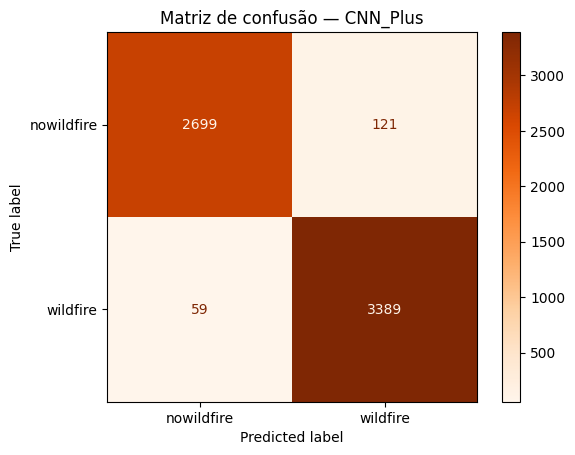

              precision    recall  f1-score   support

  nowildfire      0.979     0.957     0.968      2820
    wildfire      0.966     0.983     0.974      3448

    accuracy                          0.971      6268
   macro avg      0.972     0.970     0.971      6268
weighted avg      0.971     0.971     0.971      6268



In [17]:
# === Matriz de confusão + relatório de classificação (melhor modelo) ===
melhor = cnn_plus if res_b[1] >= res_a[1] else cnn_base
melhor_nome = melhor.name

y_true, y_prob = [], []
for imgs, labels in test_ds:
    y_true.extend(labels.numpy().ravel())
    y_prob.extend(melhor.predict(imgs, verbose=0).ravel())
y_true = np.array(y_true); y_pred = (np.array(y_prob) >= 0.5).astype(int)

cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(cmap="Oranges")
plt.title(f"Matriz de confusão — {melhor_nome}"); plt.show()
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=3))

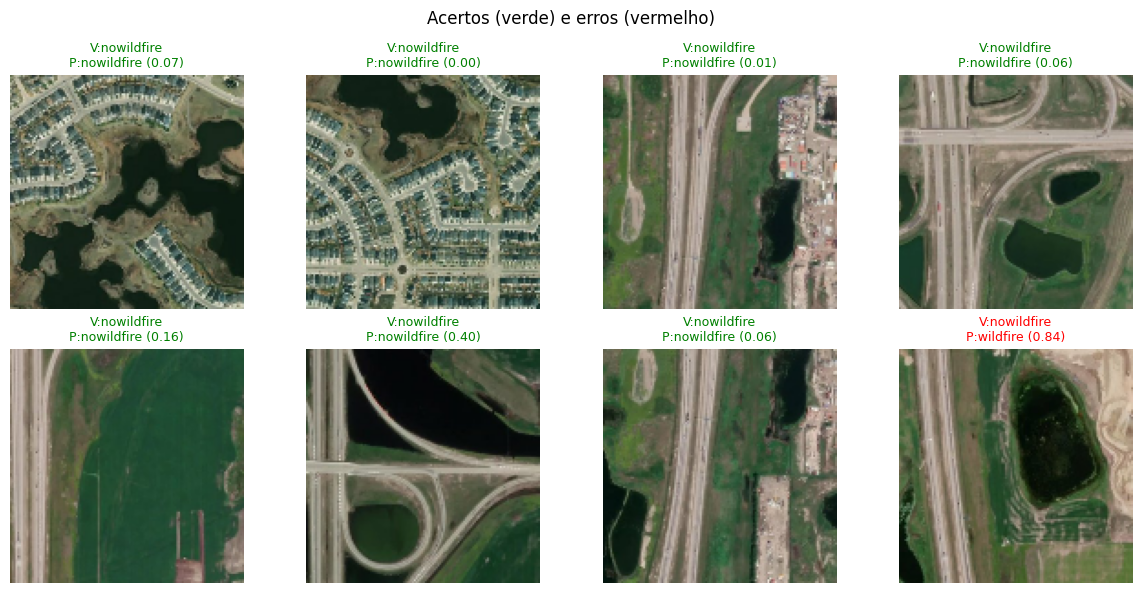

In [21]:
# === Análise qualitativa: exemplos de erros e acertos ===
imgs_test, labels_test = next(iter(test_ds))
probs = melhor.predict(imgs_test, verbose=0).ravel()
preds = (probs >= 0.5).astype(int)
verdadeiros = labels_test.numpy().ravel().astype(int)

plt.figure(figsize=(12, 6))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(imgs_test[i].numpy().astype("uint8"))
    ok = preds[i] == verdadeiros[i]
    cor = "green" if ok else "red"
    plt.title(f"V:{CLASS_NAMES[verdadeiros[i]]}\nP:{CLASS_NAMES[preds[i]]} ({probs[i]:.2f})",
              color=cor, fontsize=9)
    plt.axis("off")
plt.suptitle("Acertos (verde) e erros (vermelho)"); plt.tight_layout(); plt.show()

## 5. Comparação entre arquiteturas

In [23]:
# === Tabela comparativa ===
import pandas as pd
comp = pd.DataFrame({
    "Modelo": ["CNN-Base", "CNN-Plus"],
    "Parâmetros": [cnn_base.count_params(), cnn_plus.count_params()],
    "Acurácia (teste)": [round(res_a[1], 4), round(res_b[1], 4)],
    "Loss (teste)": [round(res_a[0], 3), round(res_b[0], 3)],
    "Atingiu 88%": ["Sim" if res_a[1] >= 0.88 else "Não",
                     "Sim" if res_b[1] >= 0.88 else "Não"],
})
comp

,Modelo,Parâmetros,Acurácia (teste),Loss (teste),Atingiu 88%
0,CNN-Base,4287809,0.9710,0.075,Sim
1,CNN-Plus,1241185,0.9713,0.077,Sim


### Justificativa técnica das diferenças

- **CNN-Base** usa `Flatten` após as convoluções, o que gera uma camada densa enorme
  (muitos parâmetros) e tende a **overfitar** em imagens de satélite, com pouca
  capacidade de generalizar — sem BatchNorm, o treino também é mais instável.
- **CNN-Plus** troca `Flatten` por **GlobalAveragePooling** (drasticamente menos
  parâmetros, menos overfitting), adiciona **BatchNormalization** (treino mais estável
  e rápido) e **Dropout** (regularização). É mais profunda, capturando padrões visuais
  mais ricos (fumaça, cicatrizes de queimada, textura de vegetação).

Conclusão esperada: **CNN-Plus supera o baseline** e atinge a referência de 88%. Caso
o baseline também passe de 88%, a diferença aparece na **estabilidade** (curvas de
validação) e no **gap treino-validação** (overfitting do CNN-Base).

In [26]:
# === Salvar o melhor modelo (pesos do melhor treino) ===
melhor.save("best_model.keras")
print(f"Modelo salvo: best_model.keras ({melhor_nome})")

Modelo salvo: best_model.keras (CNN_Plus)


## 6. Demonstração funcional

Predição em uma **imagem nova**. Substitua o caminho por uma imagem de satélite sua.
Para a demo interativa, veja `app/app_gradio.py` no repositório.

In [25]:
# === Inferência em imagem nova ===
def prever_imagem(caminho, modelo=melhor):
    img = tf.keras.utils.load_img(caminho, target_size=IMG_SIZE)
    arr = tf.expand_dims(tf.keras.utils.img_to_array(img), 0)
    p = float(modelo.predict(arr, verbose=0)[0][0])
    classe = CLASS_NAMES[int(p >= 0.5)]
    print(f"{caminho} -> {classe}  (prob wildfire={p:.3f})")
    return classe, p

# Exemplo (pega uma imagem do próprio test set como demonstração):
import glob
exemplo = glob.glob(os.path.join(TEST_DIR, "wildfire", "*"))[0]
prever_imagem(exemplo)

/kaggle/input/datasets/abdelghaniaaba/wildfire-prediction-dataset/test/wildfire/-75.23487,49.17026.jpg -> wildfire  (prob wildfire=1.000)


('wildfire', 0.9996989369392395)

## 7. Conclusão

O módulo ACV entrega duas CNNs treinadas do zero para detecção de queimadas em imagens
de satélite, integrando-se ao OrbitalFire como camada de validação visual dos alertas.
A comparação evidencia o ganho de generalização ao adotar BatchNorm, GlobalAveragePooling
e Dropout (CNN-Plus) frente ao baseline (CNN-Base).

**Se a acurácia ficar abaixo de 88%**, caminhos de melhoria: aumentar `IMG_SIZE` para
160/224, treinar mais épocas, ajustar `learning_rate` (ex.: `ReduceLROnPlateau`),
intensificar/balancear o augmentation, ou adicionar mais um bloco convolucional —
sempre mantendo o treino **do zero**, sem pesos pré-treinados.